# 02 - Features and Model

Builds features and runs two complementary anomaly detection methods:

1. **IQR scoring** - statistical, per-segment, human-explainable
2. **Isolation Forest** - ML-based, per-segment, catches multivariate patterns

Partners flagged by **both** methods are the highest-confidence alerts.

## 0. Imports

In [1]:
import sys, os
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import hashlib
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")

from config import DEFAULT_CONFIG, SEGMENT_LABELS, AUTHORITY_LIMITS, ROS_BANDWIDTH
from features.transaction_features import (
    add_reversal_ratio, add_high_value_flags,
    add_ros_score, add_round_transaction_flag,
    add_segment_label, add_transaction_type_label,
    net_cancellation_pairs,
    aggregate_to_partner_level, add_peer_zscores,
)
from detection.iqr_scoring import score_features_by_segment
from detection.isolation_forest import run_isolation_forest_by_segment
from alerts.explanations import build_alert_column

cfg = DEFAULT_CONFIG
print("Config loaded. Contamination:", cfg.thresholds.isolation_forest_contamination)
print("IQR multiplier:", cfg.thresholds.iqr_multiplier)

Config loaded. Contamination: 0.05
IQR multiplier: 2.0


## 1. Load curated gold layer

In [2]:
df = pd.read_parquet("../data/curated/business_partners")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (20605, 28)
Columns: ['BusinessPartner', 'BusinessPartnerName', 'TotalTransactions', 'TotalAmount', 'AvgAmount', 'StdAmount', 'MaxSingleAmount', 'TotalItems', 'UniqueDocTypes', 'UniqueMainTransactions', 'UniqueContracts', 'ACDocCount', 'ZCDocCount', 'HighValueCount', 'ExtremeValueCount', 'Balance', 'TotalDebit', 'TotalCredit', 'AvgDaysOverdue', 'MaxDaysOverdue', 'AvgDebitCreditRatio', 'ReversalRatio', 'AmountVolatility', 'TotalTransactions_zscore', 'MaxSingleAmount_zscore', 'ReversalRatio_zscore', 'Balance_zscore', 'TotalDebit_zscore']


## 2. Rebuild partner-level features from raw

We re-derive features here from the raw data so the notebook is self-contained and reflects exactly what `curated.py` produces.

In [3]:
raw = pd.read_csv("../data/raw/business_partners.csv", low_memory=False)
raw["AmountInDisplayCurrency"] = pd.to_numeric(raw["AmountInDisplayCurrency"], errors="coerce")
raw["BalanceAmountInDisplayCurrency"] = pd.to_numeric(raw["BalanceAmountInDisplayCurrency"], errors="coerce")
raw["DebitAmountInDisplayCrcy"] = pd.to_numeric(raw["DebitAmountInDisplayCrcy"], errors="coerce")
raw["CreditAmountInDisplayCrcy"] = pd.to_numeric(raw["CreditAmountInDisplayCrcy"], errors="coerce")

def parse_sap_date(val):
    try:
        ms = int(str(val).replace("/Date(", "").replace(")/", "").split("+")[0])
        return pd.Timestamp(ms, unit="ms")
    except:
        return pd.NaT

raw["CANetDueDate"] = raw["CANetDueDate"].apply(parse_sap_date)
raw["Amount"] = raw["AmountInDisplayCurrency"].abs()
raw["DaysOverdue"] = (pd.Timestamp.now() - raw["CANetDueDate"]).dt.days.clip(lower=0)

def anonymize(name):
    if pd.isna(name) or str(name).strip() == "":
        return "CUSTOMER_UNKNOWN"
    return "CUSTOMER_" + hashlib.md5(str(name).encode()).hexdigest()[:6].upper()

raw["BusinessPartnerName"] = raw["BusinessPartnerName"].apply(anonymize)

raw = add_reversal_ratio(raw, doc_type_col="CADocumentType")
raw = add_high_value_flags(raw, amount_col="Amount",
                            high_threshold=cfg.thresholds.high_value_threshold,
                            extreme_threshold=cfg.thresholds.extreme_value_threshold)
raw = add_ros_score(raw, amount_col="Amount",
                    authority_limits=AUTHORITY_LIMITS, bandwidth=ROS_BANDWIDTH)
raw = add_round_transaction_flag(raw, amount_col="Amount")
raw = add_segment_label(raw, segment_col="CAAccountDeterminationCode")
raw = add_transaction_type_label(raw, main_txn_col="CAMainTransaction")
raw = net_cancellation_pairs(raw, partner_col="BusinessPartner", amount_col="Amount")

partners = aggregate_to_partner_level(raw, use_netted=True)
partners = add_peer_zscores(partners)

print("Partners shape:", partners.shape)
print()
print(partners.describe().T[["mean","std","min","50%","max"]].to_string())

Cancellation matching: 4,614 rows netted out across 70 partners
Partners shape: (11844, 38)

                                    mean        std           min          50%          max
BusinessPartner             1,064,450.47  49,806.60  1,000,011.00 1,046,726.00 1,179,471.00
TotalTransactions                  21.91     307.56          1.00         2.00    19,174.00
TotalAmount                     1,343.04  15,908.01          0.01        47.91 1,288,392.57
AvgAmount                         138.44   1,445.26          0.01        24.27   107,199.47
StdAmount                         100.42   1,276.69          0.00         0.00    78,812.78
MaxSingleAmount                   491.60   5,735.77          0.01        35.20   451,636.78
TotalItems                         21.91     307.56          1.00         2.00    19,174.00
UniqueDocTypes                      1.33       0.80          1.00         1.00        13.00
UniqueMainTransactions              1.21       0.48          1.00         1.00 

## 3. Pre-model feature analysis

### 3.1 Feature distributions at model input

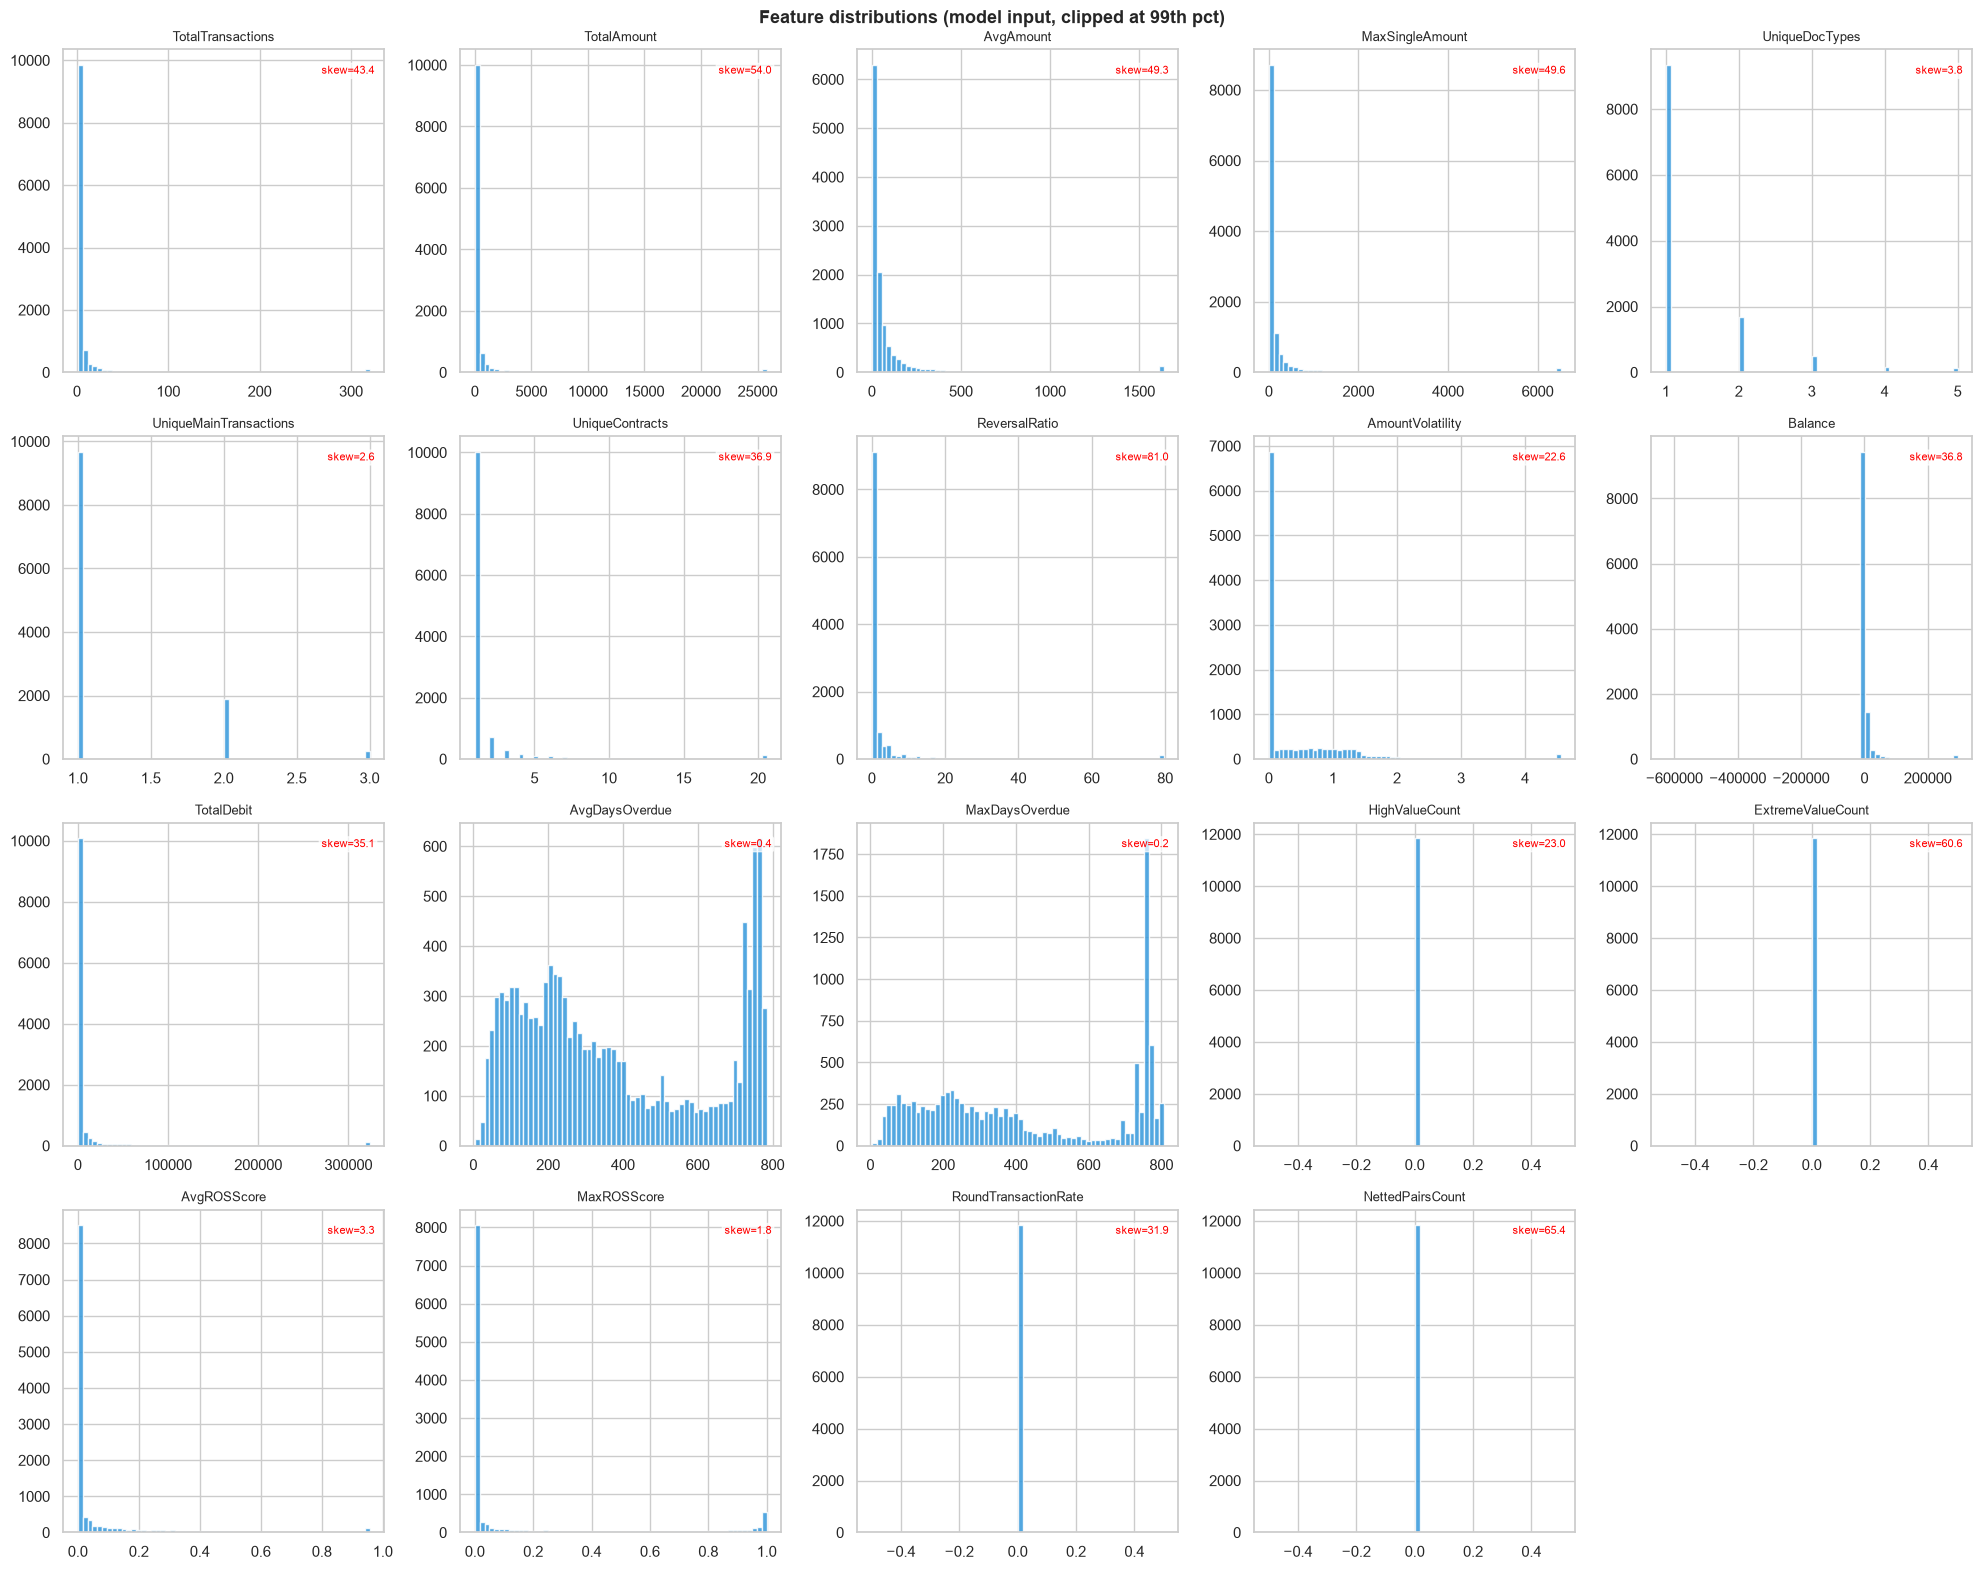

In [5]:
feature_cols = cfg.features.numeric_features
available = [c for c in feature_cols if c in partners.columns]

ncols = 5
nrows = (len(available) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, col in enumerate(available):
    data = partners[col].clip(upper=partners[col].quantile(0.99))
    axes[i].hist(data, bins=60, color="#3498db", edgecolor="white", alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    skew = partners[col].skew()
    axes[i].text(0.97, 0.95, "skew={:.1f}".format(skew),
                 transform=axes[i].transAxes, ha="right", va="top", fontsize=8,
                 color="red", bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

for j in range(len(available), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions (model input, clipped at 99th pct)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 3.2 Correlation matrix

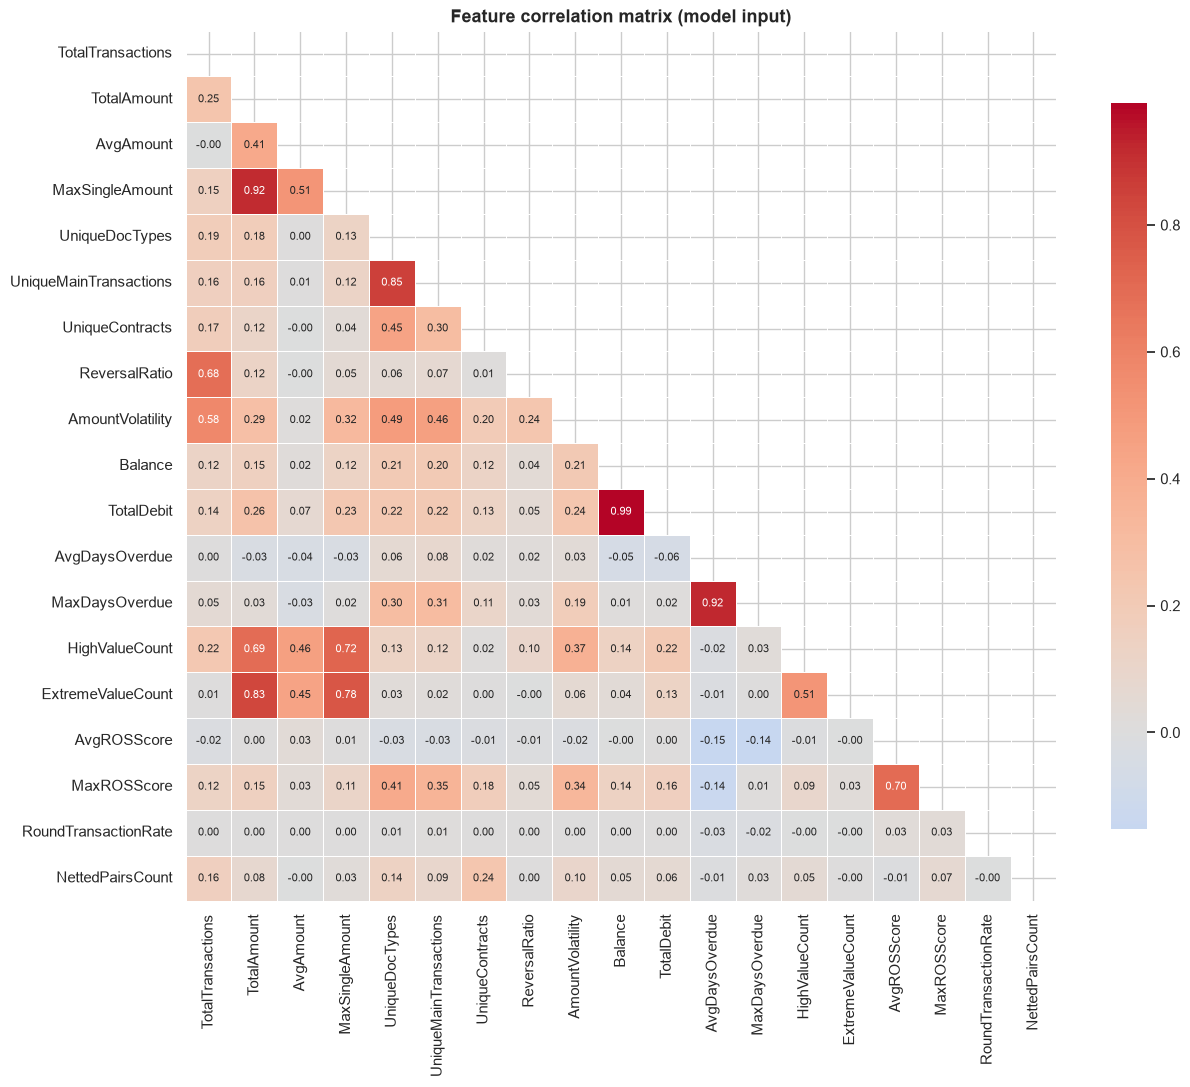

Highly correlated pairs (|r| > 0.7):
  TotalAmount               <-> MaxSingleAmount            r = 0.92
  TotalAmount               <-> ExtremeValueCount          r = 0.83
  MaxSingleAmount           <-> HighValueCount             r = 0.72
  MaxSingleAmount           <-> ExtremeValueCount          r = 0.78
  UniqueDocTypes            <-> UniqueMainTransactions     r = 0.85
  Balance                   <-> TotalDebit                 r = 0.99
  AvgDaysOverdue            <-> MaxDaysOverdue             r = 0.92


In [6]:
corr = partners[available].corr()

fig, ax = plt.subplots(figsize=(13, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
ax.set_title("Feature correlation matrix (model input)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Highly correlated pairs (|r| > 0.7):")
for i in range(len(available)):
    for j in range(i+1, len(available)):
        r = corr.iloc[i, j]
        if abs(r) > 0.7:
            print("  {:<25} <-> {:<25}  r = {:.2f}".format(available[i], available[j], r))

## 4. IQR scoring (per segment)

For each feature, compute how many IQRs above Q3 each partner sits -- within their segment. A score > 2 is flagged.

In [7]:
partners_iqr = score_features_by_segment(
    partners,
    feature_cols=available,
    segment_col="Segment",
    iqr_multiplier=cfg.thresholds.iqr_multiplier,
)

iqr_flagged = partners_iqr["iqr_flag"].sum()
print("IQR flagged: {:,} of {:,} partners ({:.1f}%)".format(
    iqr_flagged, len(partners_iqr), iqr_flagged/len(partners_iqr)*100))
print()
print("Breakdown by segment:")
print(
    partners_iqr.groupby("Segment")
    .agg(Partners=("BusinessPartner","count"), IQR_Flagged=("iqr_flag","sum"))
    .assign(PctFlagged=lambda x: (x["IQR_Flagged"]/x["Partners"]*100).round(1))
    .to_string()
)

IQR flagged: 4,883 of 11,844 partners (41.2%)

Breakdown by segment:
               Partners  IQR_Flagged  PctFlagged
Segment                                         
Corporate           190           79       41.60
Government            9            4       44.40
International         5            1       20.00
Reversal              2            0        0.00
Standard          11628         4794       41.20
Unknown              10            5       50.00


### 4.1 IQR scores for key features

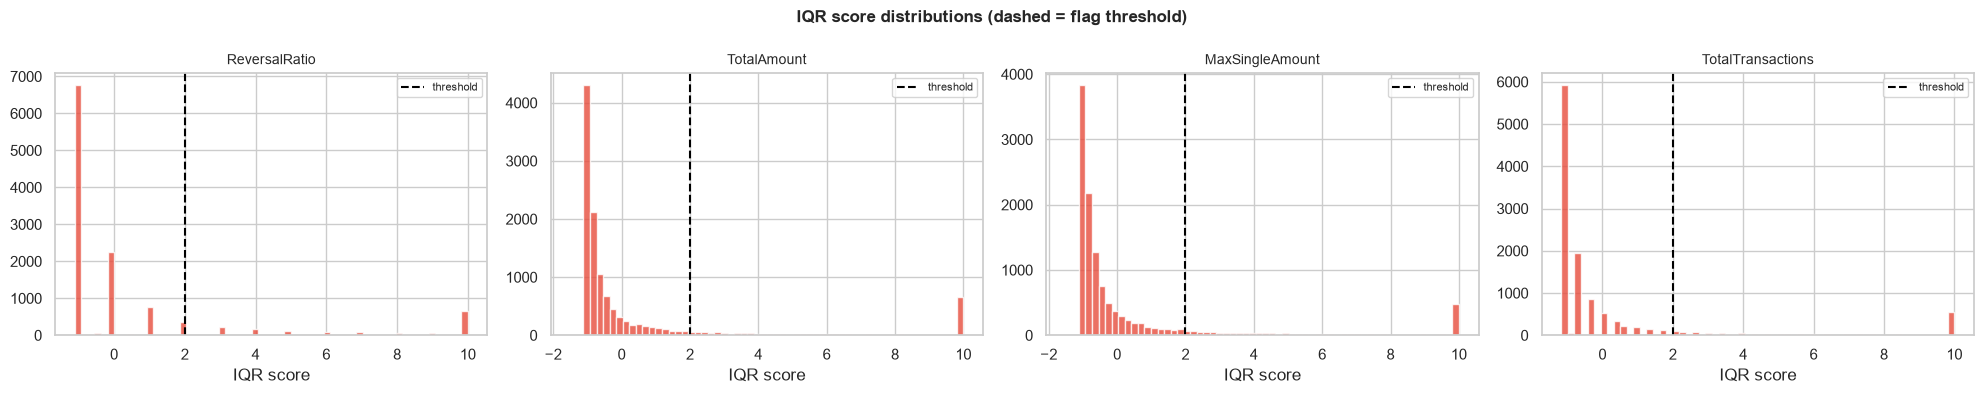

In [8]:
score_cols = [c + "_iqr_score" for c in ["ReversalRatio","TotalAmount","MaxSingleAmount","TotalTransactions"] if c + "_iqr_score" in partners_iqr.columns]

if score_cols:
    fig, axes = plt.subplots(1, len(score_cols), figsize=(5*len(score_cols), 4))
    if len(score_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, score_cols):
        data = partners_iqr[col].clip(-3, 10)
        ax.hist(data, bins=60, color="#e74c3c", edgecolor="white", alpha=0.8)
        ax.axvline(cfg.thresholds.iqr_multiplier, color="black", linestyle="--", linewidth=1.5, label="threshold")
        ax.set_title(col.replace("_iqr_score",""), fontsize=10)
        ax.set_xlabel("IQR score")
        ax.legend(fontsize=8)

    plt.suptitle("IQR score distributions (dashed = flag threshold)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()

## 5. Isolation Forest (per segment)

ML-based detection that catches multivariate patterns IQR misses. Runs independently within each segment.

In [9]:
partners_scored = run_isolation_forest_by_segment(
    partners_iqr,
    feature_cols=available,
    segment_col="Segment",
    contamination=cfg.thresholds.isolation_forest_contamination,
    n_estimators=cfg.thresholds.isolation_forest_n_estimators,
    random_state=cfg.thresholds.isolation_forest_random_state,
)

if_flagged = partners_scored["isolation_forest_flag"].sum()
print("Isolation Forest flagged: {:,} of {:,} partners ({:.1f}%)".format(
    if_flagged, len(partners_scored), if_flagged/len(partners_scored)*100))
print()
print("Breakdown by segment:")
print(
    partners_scored.groupby("Segment")
    .agg(Partners=("BusinessPartner","count"), IF_Flagged=("isolation_forest_flag","sum"))
    .assign(PctFlagged=lambda x: (x["IF_Flagged"]/x["Partners"]*100).round(1))
    .to_string()
)

Isolation Forest flagged: 601 of 11,844 partners (5.1%)

Breakdown by segment:
               Partners  IF_Flagged  PctFlagged
Segment                                        
Corporate           190          10        5.30
Government            9           4       44.40
International         5           4       80.00
Reversal              2           0        0.00
Standard          11628         582        5.00
Unknown              10           1       10.00


### 5.1 Risk score distribution

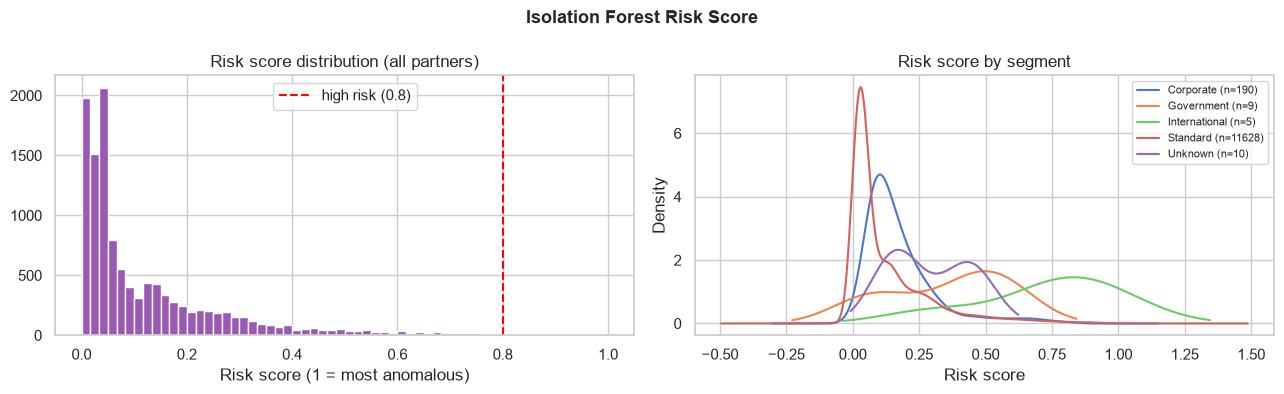

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

partners_scored["risk_score"].hist(bins=60, ax=axes[0], color="#9b59b6", edgecolor="white")
axes[0].set_title("Risk score distribution (all partners)")
axes[0].set_xlabel("Risk score (1 = most anomalous)")
axes[0].axvline(0.8, color="red", linestyle="--", label="high risk (0.8)")
axes[0].legend()

for seg, grp in partners_scored.groupby("Segment"):
    if len(grp) >= 5:
        grp["risk_score"].plot(kind="kde", ax=axes[1], label="{} (n={})".format(seg, len(grp)))
axes[1].set_title("Risk score by segment")
axes[1].set_xlabel("Risk score")
axes[1].legend(fontsize=8)

plt.suptitle("Isolation Forest Risk Score", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Combined results

Partners flagged by **both** IQR and Isolation Forest are the highest-confidence alerts. Each method catches different patterns -- agreement between them is a strong signal.

Detection overlap:
  Flagged by BOTH methods:          597  (highest confidence)
  Isolation Forest only:              4  (multivariate signal)
  IQR only:                       4,286  (single-feature spike)
  Neither (clean):                6,957


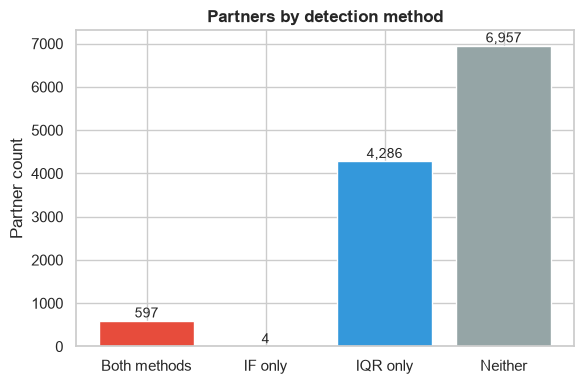

In [11]:
both   = (partners_scored["isolation_forest_flag"] & partners_scored["iqr_flag"]).sum()
if_only = (partners_scored["isolation_forest_flag"] & ~partners_scored["iqr_flag"]).sum()
iqr_only = (~partners_scored["isolation_forest_flag"] & partners_scored["iqr_flag"]).sum()
neither = (~partners_scored["isolation_forest_flag"] & ~partners_scored["iqr_flag"]).sum()

print("Detection overlap:")
print("  Flagged by BOTH methods:       {:>6,}  (highest confidence)".format(both))
print("  Isolation Forest only:         {:>6,}  (multivariate signal)".format(if_only))
print("  IQR only:                      {:>6,}  (single-feature spike)".format(iqr_only))
print("  Neither (clean):               {:>6,}".format(neither))

fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Both methods", "IF only", "IQR only", "Neither"]
values = [both, if_only, iqr_only, neither]
colors = ["#e74c3c", "#e67e22", "#3498db", "#95a5a6"]
bars = ax.bar(labels, values, color=colors, edgecolor="white")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            "{:,}".format(int(bar.get_height())), ha="center", va="bottom", fontsize=10)
ax.set_title("Partners by detection method", fontsize=12, fontweight="bold")
ax.set_ylabel("Partner count")
plt.tight_layout()
plt.show()

## 7. Add explanations and build watchlist

In [12]:
partners_final = build_alert_column(
    partners_scored,
    iqr_multiplier=cfg.thresholds.iqr_multiplier,
    suspicious_reversal_ratio=cfg.thresholds.suspicious_reversal_ratio,
    high_balance_threshold=cfg.thresholds.high_balance_threshold,
)

print("Sample flag reasons:")
sample = partners_final[
    (partners_final["isolation_forest_flag"] | partners_final["iqr_flag"]) &
    (partners_final["flag_reason"] != "")
][["BusinessPartnerName","Segment","risk_score","flag_reason"]].head(10)

for _, row in sample.iterrows():
    print()
    print("  Partner: {}  |  Segment: {}  |  Risk: {:.2f}".format(
        row["BusinessPartnerName"], row["Segment"], row["risk_score"]))
    print("  Reason:", row["flag_reason"])

Sample flag reasons:

  Partner: CUSTOMER_C98BC3  |  Segment: Standard  |  Risk: 0.24
  Reason: TotalAmount $826 is 3.9 IQRs above Standard_Receivable peers; AvgAmount (413.0) is 5.9 IQRs above Standard_Receivable peers; MaxSingleAmount $784 is 6.5 IQRs above Standard_Receivable peers; Average transaction amount is suspiciously close to authority limits (ROS score 0.18, 5.7 IQRs above Standard_Receivable peers); MaxROSScore (0.4) is 3.2 IQRs above Standard_Receivable peers

  Partner: CUSTOMER_16C3DC  |  Segment: Standard  |  Risk: 0.43
  Reason: TotalAmount $3,179 is 18.1 IQRs above Standard_Payment peers; AvgAmount (1589.3) is 25.7 IQRs above Standard_Payment peers; MaxSingleAmount $2,594 is 23.8 IQRs above Standard_Payment peers; Average transaction amount is suspiciously close to authority limits (ROS score 0.27, 9.1 IQRs above Standard_Payment peers); MaxROSScore (0.5) is 5.2 IQRs above Standard_Payment peers

  Partner: CUSTOMER_FD9C78  |  Segment: Standard  |  Risk: 0.55
  Reaso

## 8. Top 20 highest-risk partners

In [13]:
watchlist_cols = [
    "BusinessPartnerName", "Segment", "TotalTransactions", "TotalAmount",
    "MaxSingleAmount", "ReversalRatio", "Balance", "risk_score",
    "isolation_forest_flag", "iqr_flag", "flag_reason",
]
display_cols = [c for c in watchlist_cols if c in partners_final.columns]

flagged = partners_final[
    partners_final["isolation_forest_flag"] | partners_final["iqr_flag"]
].sort_values("risk_score", ascending=False)

print("TOP 20 HIGHEST RISK BUSINESS PARTNERS")
print("=" * 80)
for _, row in flagged.head(20).iterrows():
    print()
    print("  {} | Segment: {} | Risk: {:.2f} | IF: {} | IQR: {}".format(
        row["BusinessPartnerName"], row["Segment"],
        row["risk_score"],
        "YES" if row["isolation_forest_flag"] else "no",
        "YES" if row["iqr_flag"] else "no"))
    print("  Transactions: {:,}  |  Total Amount: ${:,.2f}  |  Max Single: ${:,.2f}  |  Reversal: {:.1f}x".format(
        int(row["TotalTransactions"]), row["TotalAmount"],
        row["MaxSingleAmount"], row["ReversalRatio"]))
    if row["flag_reason"]:
        print("  Reason:", row["flag_reason"])

TOP 20 HIGHEST RISK BUSINESS PARTNERS

  CUSTOMER_90BFA8 | Segment: International | Risk: 1.00 | IF: YES | IQR: YES
  Transactions: 2,719  |  Total Amount: $77,220.32  |  Max Single: $5,370.39  |  Reversal: 83.3x
  Reason: UniqueContracts (727.0) is 8.4 IQRs above International_Receivable peers; 93 AC/ZC cancellation pairs detected (2.3 IQRs above International_Receivable peers); ReversalRatio 83.3x exceeds 5.0x threshold; Balance $625,700 exceeds $100,000 threshold

  CUSTOMER_691571 | Segment: Standard | Risk: 0.99 | IF: YES | IQR: YES
  Transactions: 1,298  |  Total Amount: $79,714.28  |  Max Single: $4,535.39  |  Reversal: 15.1x
  Reason: TotalTransactions (1298.0) is 431.3 IQRs above Standard_Reversal_Adjustment peers; TotalAmount $79,714 is 480.7 IQRs above Standard_Reversal_Adjustment peers; MaxSingleAmount $4,535 is 42.5 IQRs above Standard_Reversal_Adjustment peers; ReversalRatio 15.1x is 14.1 IQRs above Standard_Reversal_Adjustment peers; AmountVolatility (4.7) is 5.3 IQRs ab

## 9. Export watchlist

In [14]:
import os
os.makedirs("../outputs", exist_ok=True)

output = flagged[display_cols].copy()
output.to_csv("../outputs/anomaly_watchlist.csv", index=False)

print("Watchlist saved to ../outputs/anomaly_watchlist.csv")
print("Total flagged: {:,}".format(len(output)))
print("  - Both methods: {:,}".format((output["isolation_forest_flag"] & output["iqr_flag"]).sum()))
print("  - IF only:      {:,}".format((output["isolation_forest_flag"] & ~output["iqr_flag"]).sum()))
print("  - IQR only:     {:,}".format((~output["isolation_forest_flag"] & output["iqr_flag"]).sum()))

Watchlist saved to ../outputs/anomaly_watchlist.csv
Total flagged: 4,887
  - Both methods: 597
  - IF only:      4
  - IQR only:     4,286


## 10. Sensitivity analysis

How sensitive are results to the contamination parameter? How confident we are in the threshold choice?

 contamination  flagged   pct
          0.01      119  1.00
          0.02      237  2.00
          0.05      593  5.01
          0.10     1185 10.01
          0.15     1777 15.00


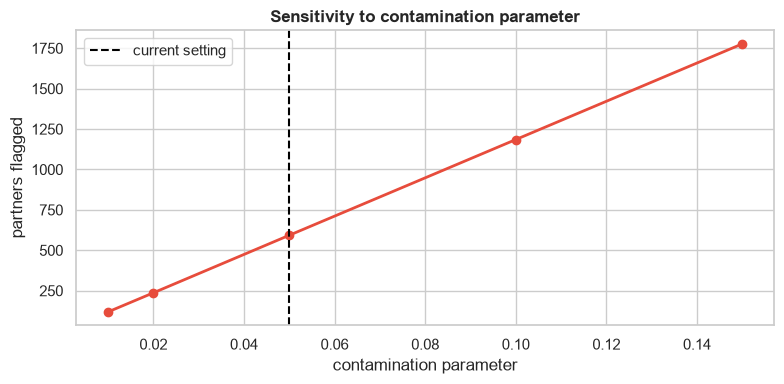

In [15]:
contamination_values = [0.01, 0.02, 0.05, 0.10, 0.15]
results = []

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

X = partners[available].fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

for c in contamination_values:
    model = IsolationForest(n_estimators=100, contamination=c, random_state=42)
    preds = model.fit_predict(X_scaled)
    n_flagged = (preds == -1).sum()
    results.append({"contamination": c, "flagged": n_flagged, "pct": n_flagged/len(X)*100})

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(res_df["contamination"], res_df["flagged"], marker="o", color="#e74c3c", linewidth=2)
ax.axvline(cfg.thresholds.isolation_forest_contamination, color="black", linestyle="--", label="current setting")
ax.set_xlabel("contamination parameter")
ax.set_ylabel("partners flagged")
ax.set_title("Sensitivity to contamination parameter", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()